# 1. Imports

In [ ]:
s

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# custom utility functions
from Minimal_Example import Params, compute_bounds, compute_labels

# cost parameters
PARAMS = Params()

# 2. Data

For brevity, we concentrate on one store-sku-combination.

In [14]:
data = pd.read_csv('data.csv')
data.head()

,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,8091,216418,106.8750,106.8750,0,0,24
1,8091,216418,106.1625,106.1625,0,0,29
2,8091,216418,106.1625,106.1625,0,0,16
3,8091,216418,106.1625,106.1625,0,0,14
4,8091,216418,99.0375,99.0375,0,0,20


# 3. Labelling

For details on the labelling process, see Minimal_Example.py and Bubak et al (2026).

## 3.1. Bounds

In [3]:
bounds = compute_bounds(D=data[['units_sold']].values, K=PARAMS.K, gamma=PARAMS.gamma, b=PARAMS.b, h=PARAMS.h, c = PARAMS.c)
bounds

(-188, 531)

## 3.2. Labels

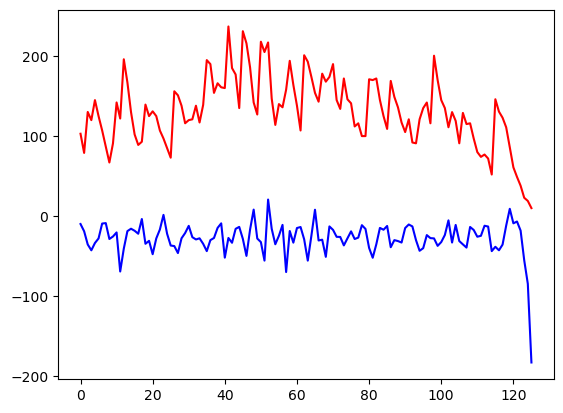

In [4]:
s_ls, S_ls = compute_labels(D=data[['units_sold']].values, K=PARAMS.K, gamma=PARAMS.gamma, b=PARAMS.b, h=PARAMS.h, c=PARAMS.c,
                            bounds=bounds)

fig, ax = plt.subplots()
ax.plot(s_ls, color='b')
ax.plot(S_ls, color='r')

In [5]:
ignore_last_n = 3 # last n values are discarded to avoid end-of-period effects 

data_labelled = data.copy().iloc[:-ignore_last_n]
data_labelled['s'] = s_ls[:-ignore_last_n]
data_labelled['S'] = S_ls[:-ignore_last_n]
data_labelled.drop(labels=['units_sold'], axis=1, inplace=True)

data_labelled.to_csv('data_labelled.csv', index=False)

# 4. Policy Learning

In [6]:
# split into training and test sets

data_labelled = pd.read_csv('data_labelled.csv')

n_train = int(.8 * len(data_labelled))
n_test = len(data_labelled) - n_train
print(n_train, n_test)

data_labelled.iloc[:n_train].to_csv('data_train.csv', index=False)
data_labelled.iloc[n_train:].to_csv('data_test.csv', index=False)

98 25


In [7]:
# train any (suitable) regression model

data_train = pd.read_csv('data_train.csv')
X_train, y_train = data_labelled.iloc[:n_train, :-2], data_labelled.iloc[:n_train, -2:]

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# 5. Prediction & Evaluation

In [8]:
data_test = pd.read_csv('data_test.csv')
X_test, y_test = data_labelled.iloc[:n_test, :-2], data_labelled.iloc[:n_test, -2:]

y_preds = rf.predict(X_test)
s_preds, S_preds = y_preds[:, 0], y_preds[:, 1]

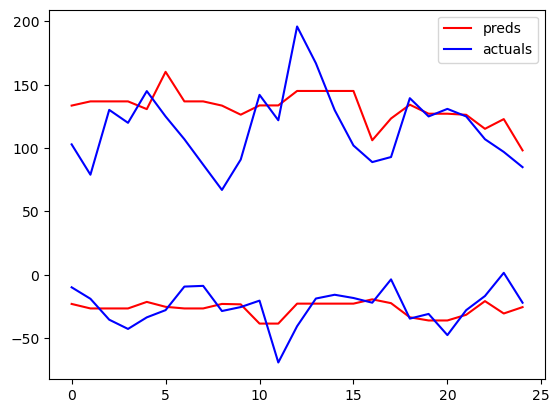

In [9]:
fig, ax = plt.subplots()
ax.plot(s_preds, color='r', label='preds')
ax.plot(S_preds, color='r')
ax.plot(y_test.iloc[:, 0], color='b', label='actuals')
ax.plot(y_test.iloc[:, 1], color='b')
ax.legend()

Total Cost during Test Period: 3020.285018058221


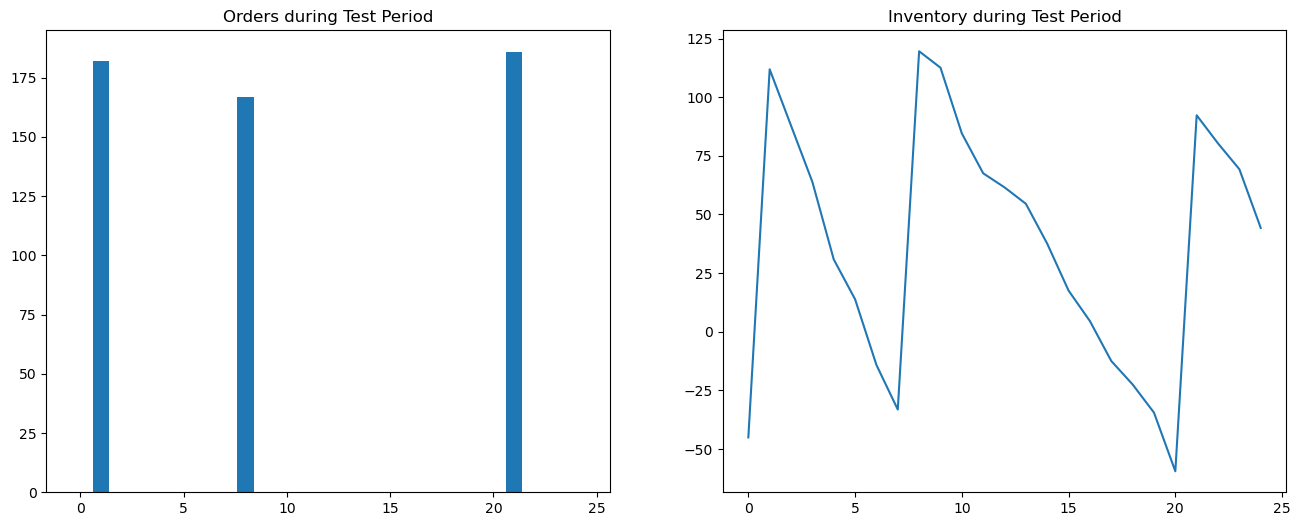

In [10]:
demand_test = pd.read_csv('data.csv')['units_sold'].values[n_train:]

q_ls, I_ls = [], []

I = 0
cost = 0
for d, s, S in zip(demand_test, s_preds, S_preds):
    
    q = S-I if I<s else 0    
    I += q-d
    cost_t = PARAMS.K*(q>0) + PARAMS.c*q + PARAMS.h*max(I,0) + PARAMS.b*max(-I,0)
    cost += cost_t
    q_ls.append(q)
    I_ls.append(I)

    
fig, axes = plt.subplots(ncols=2, figsize=(16, 6))

axes[0].bar(range(len(q_ls)), q_ls)
axes[0].set_title('Orders during Test Period')
axes[1].plot(I_ls)
axes[1].set_title('Inventory during Test Period')
print('Total Cost during Test Period:', cost)